<a href="https://colab.research.google.com/github/Shelkeyogesh812/Data-Analytic-projects/blob/main/zomato_project_DA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('https://github.com//Taj1920/Data-Analysis-Datasets/raw/refs/heads/main/Datasets-Practice/zomato_cleaned_data.csv')

In [ ]:
df

,Unnamed: 0,name,online_order,book_table,rate,votes,location,rest_type,cuisines,costfor2,type
0,0,Jalsa,Yes,Yes,4.100000,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet
1,1,Spice Elephant,Yes,No,4.100000,787,Banashankari,Casual Dining,others,800,Buffet
2,2,San Churro Cafe,Yes,No,3.800000,918,Banashankari,others,others,800,Buffet
3,3,Addhuri Udupi Bhojana,No,No,3.700000,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet
4,4,Grand Village,No,No,3.800000,166,Basavanagudi,Casual Dining,others,600,Buffet
...,...,...,...,...,...,...,...,...,...,...,...
51037,51604,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.600000,27,Whitefield,others,Continental,1500,Pubs and bars
51038,51605,Vinod Bar And Restaurant,No,No,3.700142,0,Whitefield,others,Finger Food,600,Pubs and bars
51039,51606,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,3.700142,0,Whitefield,others,Finger Food,2000,Pubs and bars
51040,51607,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.300000,236,others,others,Finger Food,2500,Pubs and bars


In [ ]:
df.rename(columns={'name':'restaurant_name', 'location': 'restaurant_location',
                   'online_order':'online_order_available', 'type' : 'restaurant_type',
    'book_table':'table_booking', 'rate':'rating', 'votes':'total_votes','costfor2':'cost_for_two'},
          inplace=True)

In [ ]:
df

,Unnamed: 0,restaurant_name,online_order_available,table_booking,rating,total_votes,restaurant_location,rest_type,cuisines,cost_for_two,restaurant_type
0,0,Jalsa,Yes,Yes,4.100000,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet
1,1,Spice Elephant,Yes,No,4.100000,787,Banashankari,Casual Dining,others,800,Buffet
2,2,San Churro Cafe,Yes,No,3.800000,918,Banashankari,others,others,800,Buffet
3,3,Addhuri Udupi Bhojana,No,No,3.700000,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet
4,4,Grand Village,No,No,3.800000,166,Basavanagudi,Casual Dining,others,600,Buffet
...,...,...,...,...,...,...,...,...,...,...,...
51037,51604,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.600000,27,Whitefield,others,Continental,1500,Pubs and bars
51038,51605,Vinod Bar And Restaurant,No,No,3.700142,0,Whitefield,others,Finger Food,600,Pubs and bars
51039,51606,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,3.700142,0,Whitefield,others,Finger Food,2000,Pubs and bars
51040,51607,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.300000,236,others,others,Finger Food,2500,Pubs and bars


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51042 entries, 0 to 51041
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              51042 non-null  int64  
 1   restaurant_name         51042 non-null  object 
 2   online_order_available  51042 non-null  object 
 3   table_booking           51042 non-null  object 
 4   rating                  51042 non-null  float64
 5   total_votes             51042 non-null  int64  
 6   restaurant_location     51042 non-null  object 
 7   rest_type               51042 non-null  object 
 8   cuisines                51042 non-null  object 
 9   cost_for_two            51042 non-null  int64  
 10  restaurant_type         51042 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 4.3+ MB


In [ ]:
mapping = {
    'Yes':1,
    'No':0
}

df['online_order_available'] = df['online_order_available'].map(mapping)
df['table_booking'] = df['table_booking'].map(mapping)

In [ ]:
df

,Unnamed: 0,restaurant_name,online_order_available,table_booking,rating,total_votes,restaurant_location,rest_type,cuisines,cost_for_two,restaurant_type
0,0,Jalsa,1,1,4.100000,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet
1,1,Spice Elephant,1,0,4.100000,787,Banashankari,Casual Dining,others,800,Buffet
2,2,San Churro Cafe,1,0,3.800000,918,Banashankari,others,others,800,Buffet
3,3,Addhuri Udupi Bhojana,0,0,3.700000,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet
4,4,Grand Village,0,0,3.800000,166,Basavanagudi,Casual Dining,others,600,Buffet
...,...,...,...,...,...,...,...,...,...,...,...
51037,51604,Best Brews - Four Points by Sheraton Bengaluru...,0,0,3.600000,27,Whitefield,others,Continental,1500,Pubs and bars
51038,51605,Vinod Bar And Restaurant,0,0,3.700142,0,Whitefield,others,Finger Food,600,Pubs and bars
51039,51606,Plunge - Sheraton Grand Bengaluru Whitefield H...,0,0,3.700142,0,Whitefield,others,Finger Food,2000,Pubs and bars
51040,51607,Chime - Sheraton Grand Bengaluru Whitefield Ho...,0,1,4.300000,236,others,others,Finger Food,2500,Pubs and bars


In [ ]:
df['restaurant_location'] = df['restaurant_location'].str.title()
df['cuisines'] = df['cuisines'].str.title()

In [ ]:
df

,Unnamed: 0,restaurant_name,online_order_available,table_booking,rating,total_votes,restaurant_location,rest_type,cuisines,cost_for_two,restaurant_type
0,0,Jalsa,1,1,4.100000,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet
1,1,Spice Elephant,1,0,4.100000,787,Banashankari,Casual Dining,Others,800,Buffet
2,2,San Churro Cafe,1,0,3.800000,918,Banashankari,others,Others,800,Buffet
3,3,Addhuri Udupi Bhojana,0,0,3.700000,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet
4,4,Grand Village,0,0,3.800000,166,Basavanagudi,Casual Dining,Others,600,Buffet
...,...,...,...,...,...,...,...,...,...,...,...
51037,51604,Best Brews - Four Points by Sheraton Bengaluru...,0,0,3.600000,27,Whitefield,others,Continental,1500,Pubs and bars
51038,51605,Vinod Bar And Restaurant,0,0,3.700142,0,Whitefield,others,Finger Food,600,Pubs and bars
51039,51606,Plunge - Sheraton Grand Bengaluru Whitefield H...,0,0,3.700142,0,Whitefield,others,Finger Food,2000,Pubs and bars
51040,51607,Chime - Sheraton Grand Bengaluru Whitefield Ho...,0,1,4.300000,236,Others,others,Finger Food,2500,Pubs and bars


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51042 entries, 0 to 51041
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              51042 non-null  int64  
 1   restaurant_name         51042 non-null  object 
 2   online_order_available  51042 non-null  int64  
 3   table_booking           51042 non-null  int64  
 4   rating                  51042 non-null  float64
 5   total_votes             51042 non-null  int64  
 6   restaurant_location     51042 non-null  object 
 7   rest_type               51042 non-null  object 
 8   cuisines                51042 non-null  object 
 9   cost_for_two            51042 non-null  int64  
 10  restaurant_type         51042 non-null  object 
dtypes: float64(1), int64(5), object(5)
memory usage: 4.3+ MB


In [ ]:
df['online_order_available'] = df['online_order_available'].astype('category')
df['table_booking'] = df['table_booking'].astype('category')
df['restaurant_type'] = df['restaurant_type'].astype('category')

In [ ]:
df

,Unnamed: 0,restaurant_name,online_order_available,table_booking,rating,total_votes,restaurant_location,rest_type,cuisines,cost_for_two,restaurant_type
0,0,Jalsa,1,1,4.100000,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet
1,1,Spice Elephant,1,0,4.100000,787,Banashankari,Casual Dining,Others,800,Buffet
2,2,San Churro Cafe,1,0,3.800000,918,Banashankari,others,Others,800,Buffet
3,3,Addhuri Udupi Bhojana,0,0,3.700000,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet
4,4,Grand Village,0,0,3.800000,166,Basavanagudi,Casual Dining,Others,600,Buffet
...,...,...,...,...,...,...,...,...,...,...,...
51037,51604,Best Brews - Four Points by Sheraton Bengaluru...,0,0,3.600000,27,Whitefield,others,Continental,1500,Pubs and bars
51038,51605,Vinod Bar And Restaurant,0,0,3.700142,0,Whitefield,others,Finger Food,600,Pubs and bars
51039,51606,Plunge - Sheraton Grand Bengaluru Whitefield H...,0,0,3.700142,0,Whitefield,others,Finger Food,2000,Pubs and bars
51040,51607,Chime - Sheraton Grand Bengaluru Whitefield Ho...,0,1,4.300000,236,Others,others,Finger Food,2500,Pubs and bars


In [ ]:
new_order = [1,6,7,8,9,4,5,2,3,10]
df = df[df.columns[new_order]]

In [ ]:
df['rest_type'] = df['rest_type'].str.replace('Quick Bites','Quick Service')

/tmp/ipykernel_565/759291669.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rest_type'] = df['rest_type'].str.replace('Quick Bites','Quick Service')


In [ ]:
df

,restaurant_name,restaurant_location,rest_type,cuisines,cost_for_two,rating,total_votes,online_order_available,table_booking,restaurant_type
0,Jalsa,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,4.100000,775,1,1,Buffet
1,Spice Elephant,Banashankari,Casual Dining,Others,800,4.100000,787,1,0,Buffet
2,San Churro Cafe,Banashankari,others,Others,800,3.800000,918,1,0,Buffet
3,Addhuri Udupi Bhojana,Banashankari,Quick Service,"South Indian, North Indian",300,3.700000,88,0,0,Buffet
4,Grand Village,Basavanagudi,Casual Dining,Others,600,3.800000,166,0,0,Buffet
...,...,...,...,...,...,...,...,...,...,...
51037,Best Brews - Four Points by Sheraton Bengaluru...,Whitefield,others,Continental,1500,3.600000,27,0,0,Pubs and bars
51038,Vinod Bar And Restaurant,Whitefield,others,Finger Food,600,3.700142,0,0,0,Pubs and bars
51039,Plunge - Sheraton Grand Bengaluru Whitefield H...,Whitefield,others,Finger Food,2000,3.700142,0,0,0,Pubs and bars
51040,Chime - Sheraton Grand Bengaluru Whitefield Ho...,Others,others,Finger Food,2500,4.300000,236,0,1,Pubs and bars


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51042 entries, 0 to 51041
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   restaurant_name         51042 non-null  object  
 1   restaurant_location     51042 non-null  object  
 2   rest_type               51042 non-null  object  
 3   cuisines                51042 non-null  object  
 4   cost_for_two            51042 non-null  int64   
 5   rating                  51042 non-null  float64 
 6   total_votes             51042 non-null  int64   
 7   online_order_available  51042 non-null  category
 8   table_booking           51042 non-null  category
 9   restaurant_type         51042 non-null  category
dtypes: category(3), float64(1), int64(2), object(4)
memory usage: 2.9+ MB


In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
df

,restaurant_name,restaurant_location,rest_type,cuisines,cost_for_two,rating,total_votes,online_order_available,table_booking,restaurant_type
0,Jalsa,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,4.100000,775,1,1,Buffet
1,Spice Elephant,Banashankari,Casual Dining,Others,800,4.100000,787,1,0,Buffet
2,San Churro Cafe,Banashankari,others,Others,800,3.800000,918,1,0,Buffet
3,Addhuri Udupi Bhojana,Banashankari,Quick Service,"South Indian, North Indian",300,3.700000,88,0,0,Buffet
4,Grand Village,Basavanagudi,Casual Dining,Others,600,3.800000,166,0,0,Buffet
...,...,...,...,...,...,...,...,...,...,...
51037,Best Brews - Four Points by Sheraton Bengaluru...,Whitefield,others,Continental,1500,3.600000,27,0,0,Pubs and bars
51038,Vinod Bar And Restaurant,Whitefield,others,Finger Food,600,3.700142,0,0,0,Pubs and bars
51039,Plunge - Sheraton Grand Bengaluru Whitefield H...,Whitefield,others,Finger Food,2000,3.700142,0,0,0,Pubs and bars
51040,Chime - Sheraton Grand Bengaluru Whitefield Ho...,Others,others,Finger Food,2500,4.300000,236,0,1,Pubs and bars


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51042 entries, 0 to 51041
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   restaurant_name         51042 non-null  object  
 1   restaurant_location     51042 non-null  object  
 2   rest_type               51042 non-null  object  
 3   cuisines                51042 non-null  object  
 4   cost_for_two            51042 non-null  int64   
 5   rating                  51042 non-null  float64 
 6   total_votes             51042 non-null  int64   
 7   online_order_available  51042 non-null  category
 8   table_booking           51042 non-null  category
 9   restaurant_type         51042 non-null  category
dtypes: category(3), float64(1), int64(2), object(4)
memory usage: 2.9+ MB


In [ ]:
pd.DataFrame(df.groupby('restaurant_location')['restaurant_name'].count()).reset_index()

,restaurant_location,restaurant_name
0,Banashankari,902
1,Banaswadi,640
2,Bannerghatta Road,1609
3,Basavanagudi,684
4,Bellandur,1268
5,Brigade Road,1210
6,Brookefield,656
7,Btm,5056
8,Church Street,566
9,Commercial Street,370


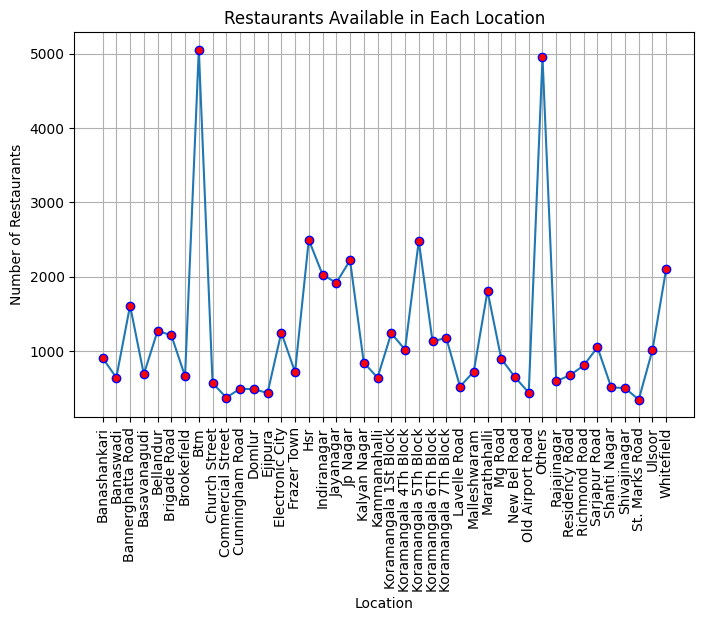

In [ ]:
#Analysis 1

#Which locations have the highest number of restaurants?

plt.figure(figsize=(8,5))

location = pd.DataFrame(
    df.groupby('restaurant_location')['restaurant_name'].count()
)

location.reset_index(inplace=True)

plt.plot(location['restaurant_location'],
         location['restaurant_name'],
         marker='o',
         markerfacecolor='red',
         markeredgecolor='blue')

plt.xlabel('Location')
plt.ylabel('Number of Restaurants')
plt.title('Restaurants Available in Each Location')
plt.xticks(rotation=90)
plt.grid(True)

plt.show()

In [ ]:
#This analysis showed us where most restaurants are located.
#We found that some places have a lot more restaurants than others.
#'Btm' and 'Koramangala 5th Block' really stand out as having tons of eateries.
#'Whitefield' also has a very high number of restaurants.
#This tells us that these areas are major food hubs with lots of choices!

In [ ]:
#Analysis 3

#Which restaurant types receive the highest number of votes?

plt.figure(figsize=(9,5))

votes = pd.DataFrame(
    df.groupby('restaurant_type')['total_votes'].sum()
)

votes.reset_index(inplace=True)

votes

/tmp/ipykernel_565/2859825950.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('restaurant_type')['total_votes'].sum()


,restaurant_type,total_votes
0,Buffet,871526
1,Cafes,821558
2,Delivery,5236082
3,Desserts,536938
4,Dine-out,5115468
5,Drinks & nightlife,1247364
6,Pubs and bars,692906


<Figure size 900x500 with 0 Axes>

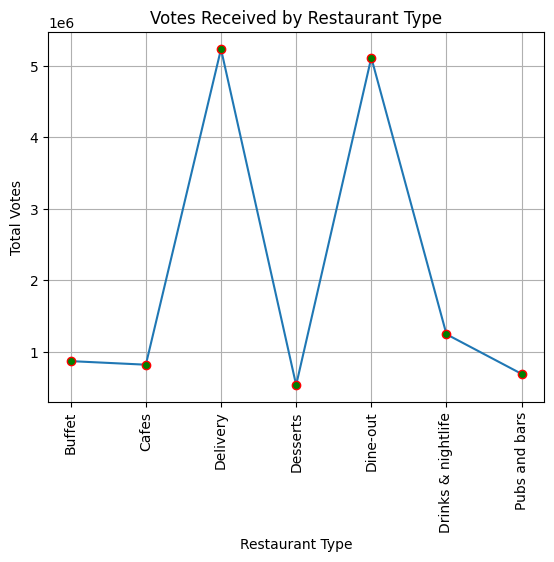

In [ ]:
plt.plot(votes['restaurant_type'],
         votes['total_votes'],
         marker='o',
         markerfacecolor='green',
         markeredgecolor='red')

plt.xlabel('Restaurant Type')

plt.ylabel('Total Votes')

plt.title('Votes Received by Restaurant Type')

plt.xticks(rotation=90)

plt.grid(True)

plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51042 entries, 0 to 51041
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   restaurant_name         51042 non-null  object  
 1   restaurant_location     51042 non-null  object  
 2   rest_type               51042 non-null  object  
 3   cuisines                51042 non-null  object  
 4   cost_for_two            51042 non-null  int64   
 5   rating                  51042 non-null  float64 
 6   total_votes             51042 non-null  int64   
 7   online_order_available  51042 non-null  category
 8   table_booking           51042 non-null  category
 9   restaurant_type         51042 non-null  category
dtypes: category(3), float64(1), int64(2), object(4)
memory usage: 2.9+ MB


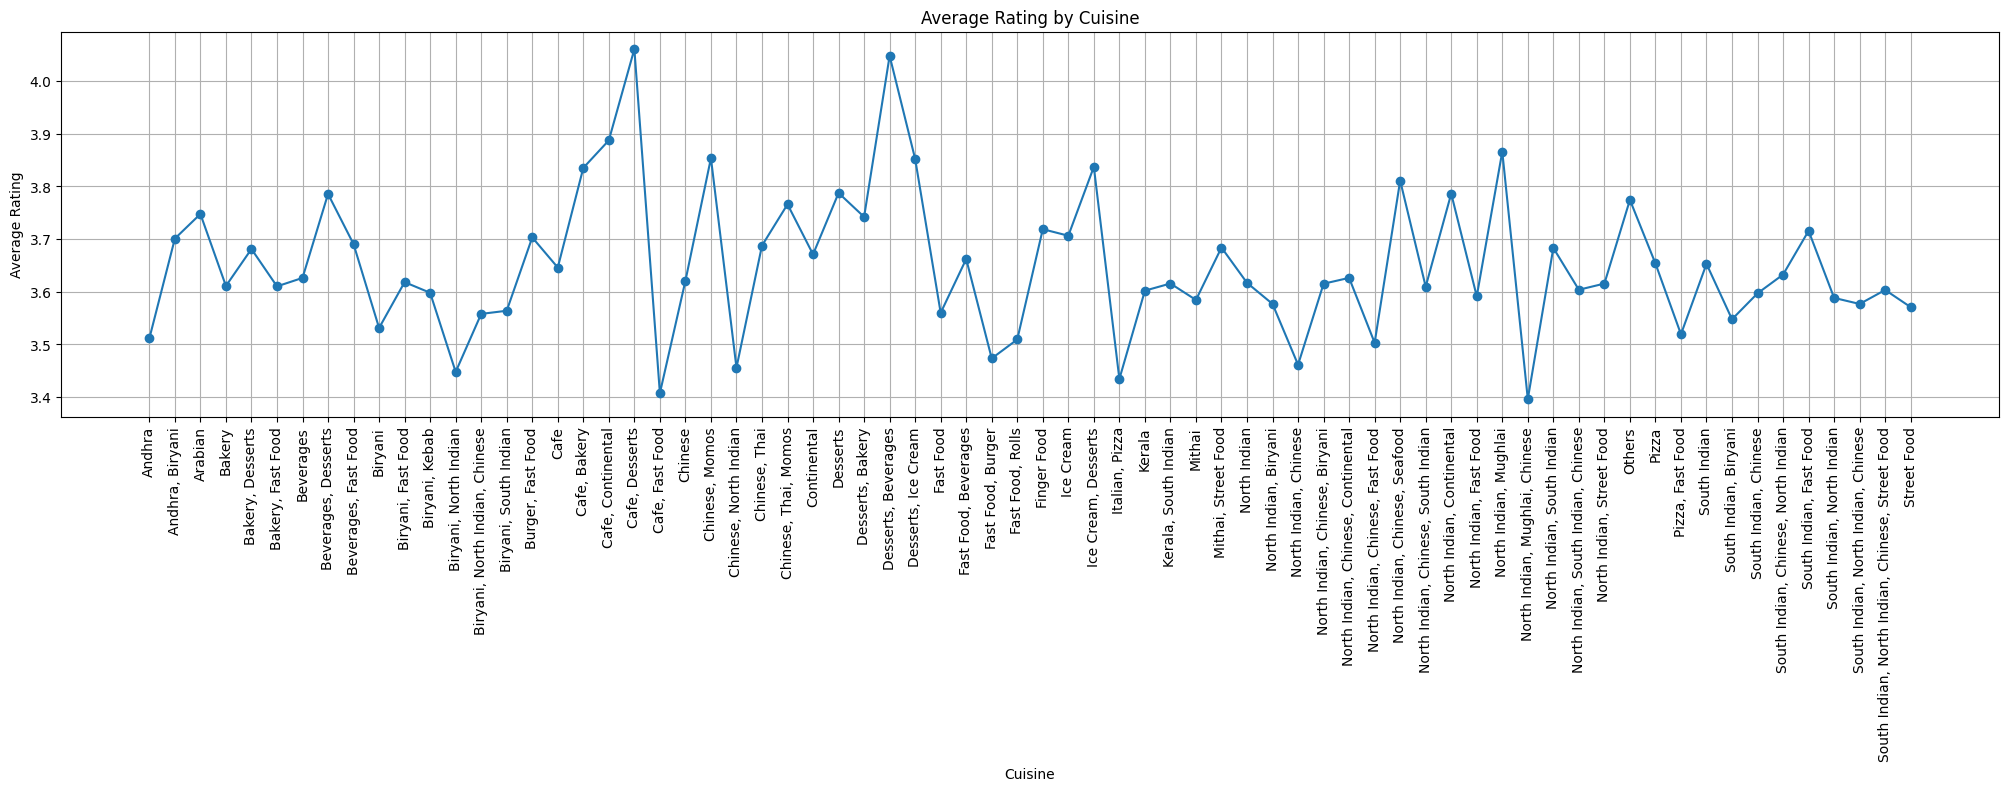

In [ ]:
#Analysis 4
#Which cuisine types have the highest average ratings?

plt.figure(figsize=(25,5))

cuisine = pd.DataFrame(
    df.groupby('cuisines')['rating'].mean()
)

cuisine.reset_index(inplace=True)

plt.plot(cuisine['cuisines'],
         cuisine['rating'],
         marker='o')

plt.xlabel('Cuisine')

plt.ylabel('Average Rating')

plt.title('Average Rating by Cuisine')

plt.xticks(rotation=90)

plt.grid(True)

plt.show()

/tmp/ipykernel_565/2752512164.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('restaurant_type')['cost_for_two'].mean()


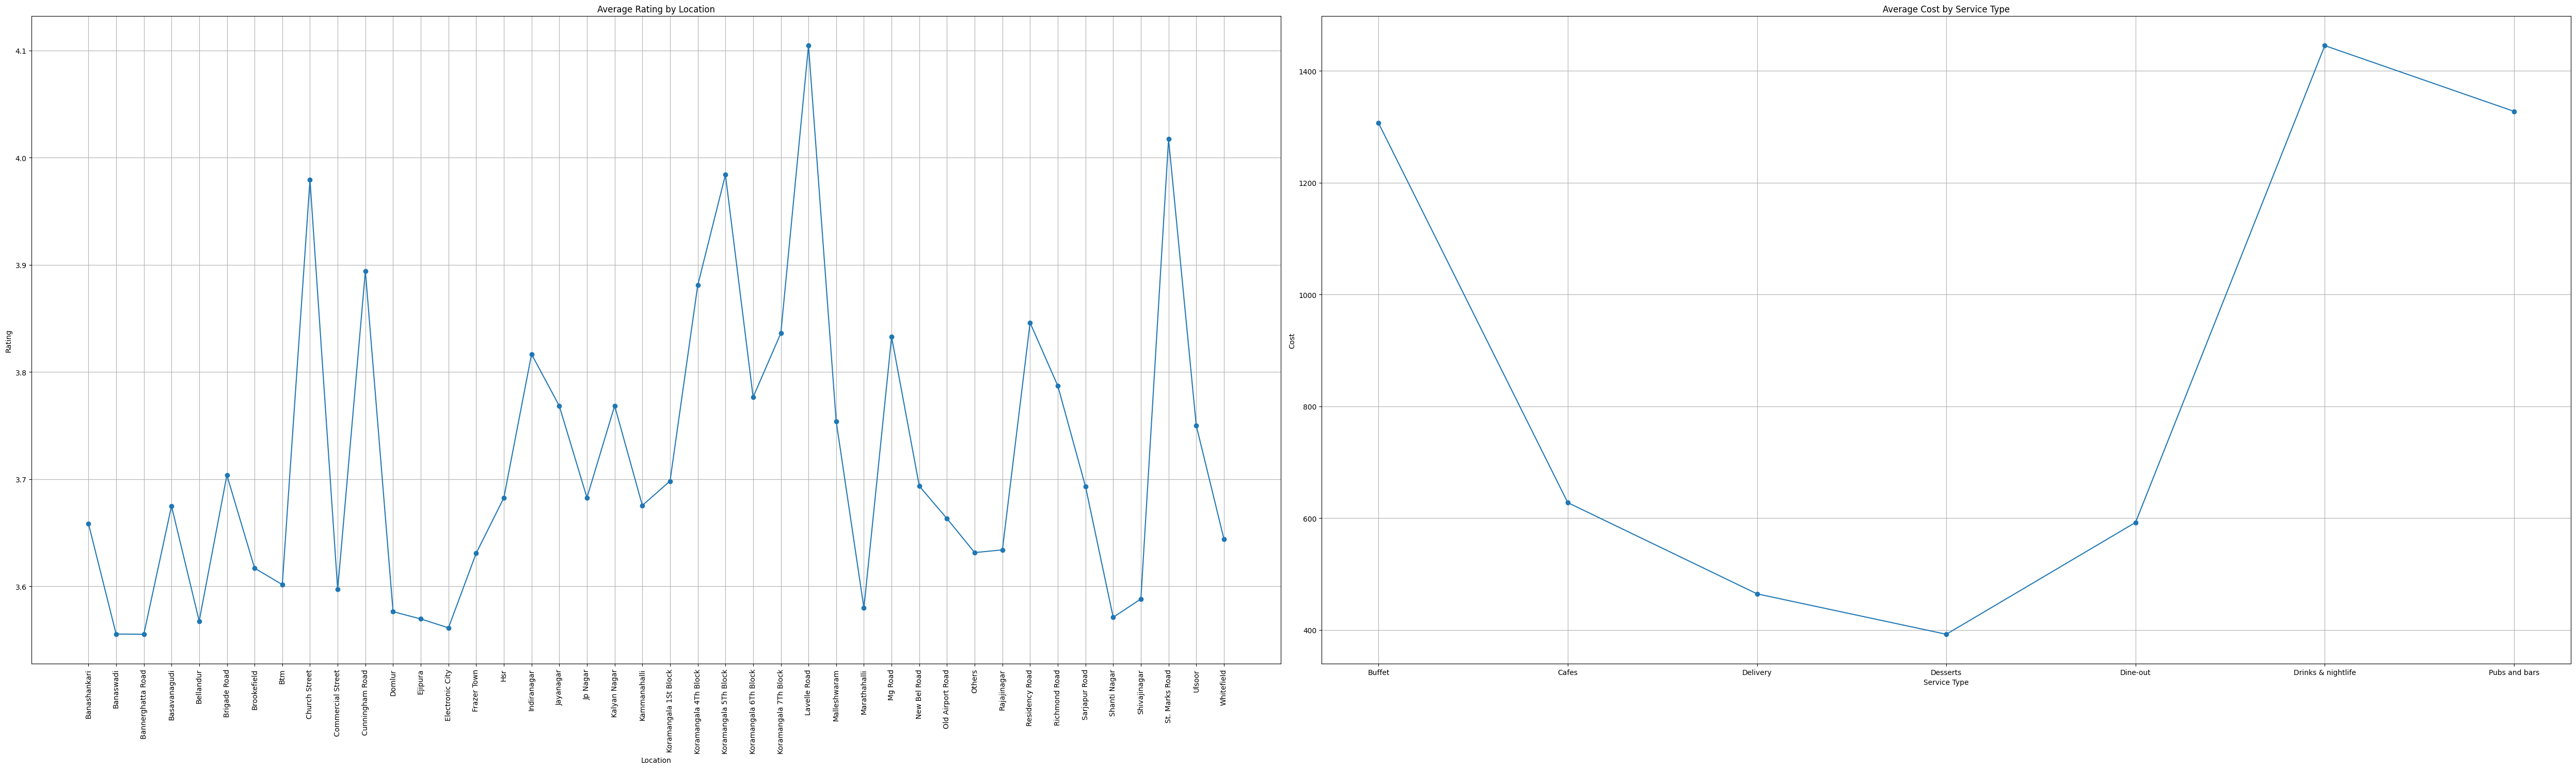

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(50,15))

# Average Rating by Location

plt.subplot(1,2,1)

rating = pd.DataFrame(
    df.groupby('restaurant_location')['rating'].mean()
)

rating.reset_index(inplace=True)

plt.plot(rating['restaurant_location'],
         rating['rating'],
         marker='o')

plt.xticks(rotation=90)

plt.xlabel('Location')

plt.ylabel('Rating')

plt.title('Average Rating by Location')

plt.grid(True)

# Average Cost by Service Type

plt.subplot(1,2,2)

cost = pd.DataFrame(
    df.groupby('restaurant_type')['cost_for_two'].mean()
)

cost.reset_index(inplace=True)

plt.plot(cost['restaurant_type'],
         cost['cost_for_two'],
         marker='o')

plt.xlabel('Service Type')

plt.ylabel('Cost')

plt.title('Average Cost by Service Type')

plt.grid(True)

plt.tight_layout()

plt.show()

/tmp/ipykernel_565/1512559047.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('restaurant_type')['restaurant_name'].count()


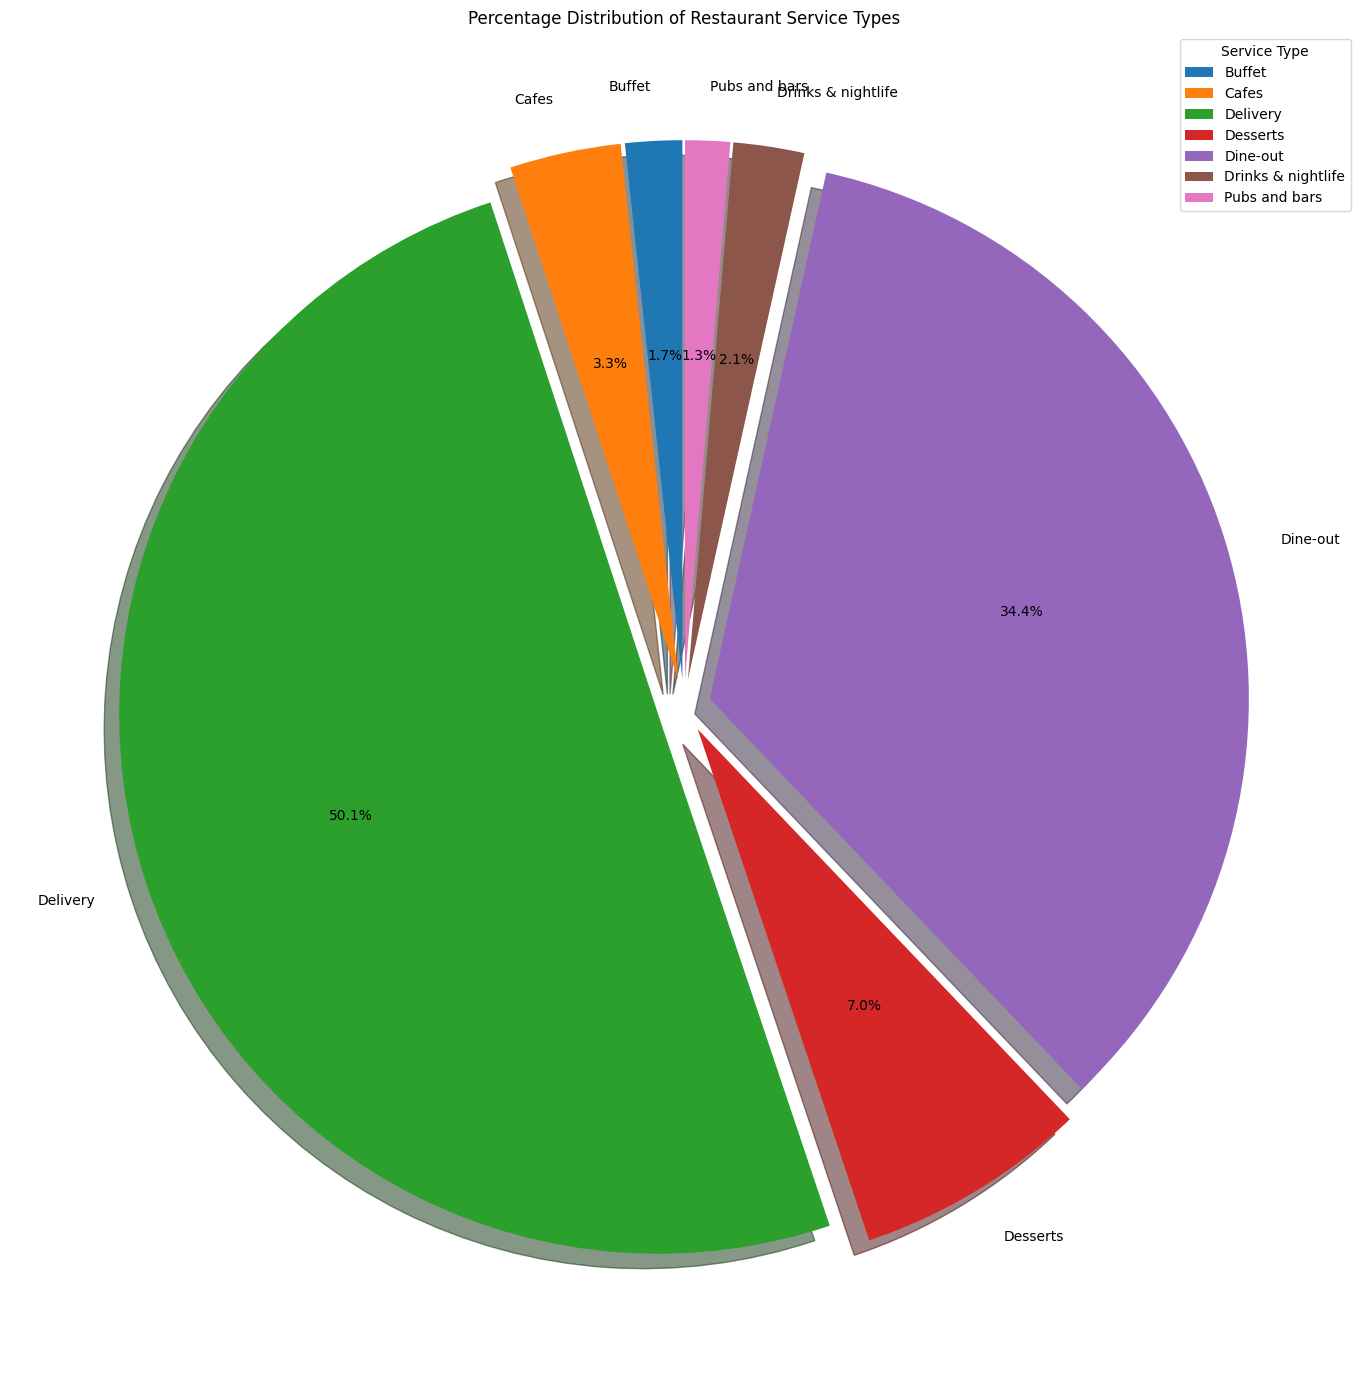

In [ ]:
# Analysis 7
# What is the percentage distribution of different Restaurant Service Types?

# Group the dataset by service type and count the number of restaurants
service = pd.DataFrame(
    df.groupby('restaurant_type')['restaurant_name'].count()
)

# Convert index into a normal column
service.reset_index(inplace=True)

# Create a figure
plt.figure(figsize=(16, 14))

# Draw the pie chart
plt.pie(
    service['restaurant_name'],
    labels=service['restaurant_type'],
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    explode=[0.05] * len(service)
)

# Give title to the chart
plt.title('Percentage Distribution of Restaurant Service Types')

# Display legend
plt.legend(
    service['restaurant_type'],
    title='Service Type',
    loc='upper right'
)

plt.tight_layout()

# Display the chart
plt.show()

  online_order_available  restaurant_name
0                      0            20814
1                      1            30228


/tmp/ipykernel_565/2097700619.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('online_order_available')['restaurant_name'].count()


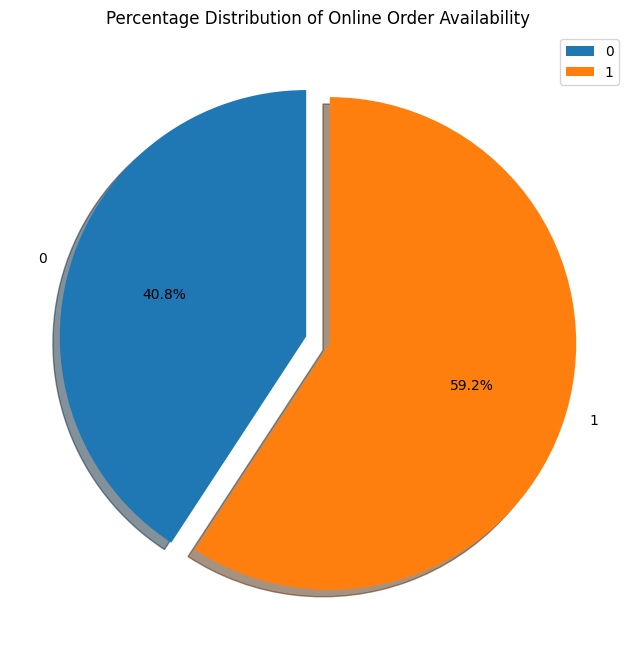

In [ ]:
# Analysis 8
# What is the percentage distribution of restaurants that provide Online Ordering?

# Group the data based on online order availability
online_order = pd.DataFrame(
    df.groupby('online_order_available')['restaurant_name'].count()
)

# Convert the grouped index into a normal column
online_order.reset_index(inplace=True)

# Display the grouped dataframe
print(online_order)

# Create a pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    online_order['restaurant_name'],
    labels=online_order['online_order_available'],
    autopct='%1.1f%%',          # Display percentage on each slice
    startangle=90,              # Start chart from 90 degrees
    shadow=True,                # Add shadow effect
    explode=[0.05] * len(online_order)   # Slightly separate each slice
)

# Add chart title
plt.title('Percentage Distribution of Online Order Availability')

# Display legend
plt.legend(online_order['online_order_available'], loc='upper right')

# Display the chart
plt.show()

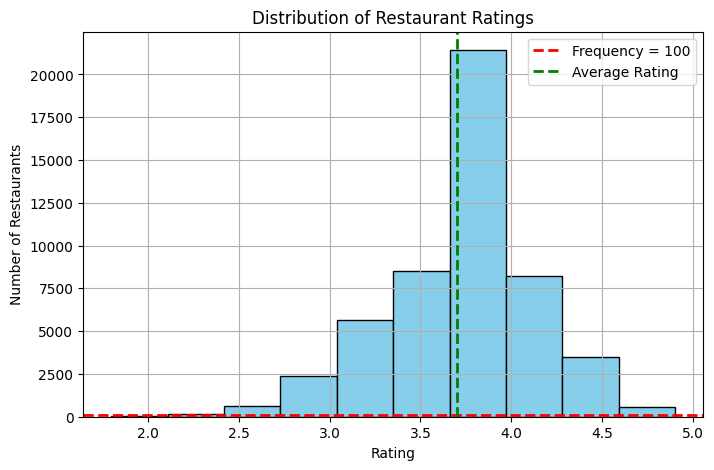

In [ ]:
# Analysis 9
# How are restaurant ratings distributed in the dataset?

# Create a figure
plt.figure(figsize=(8, 5))

# Plot histogram of ratings
plt.hist(
    df['rating'],
    bins=10,              # Divide ratings into 10 intervals
    edgecolor='black',
    color='skyblue'
)

# Draw a horizontal line at frequency = 100 (optional)
plt.axhline(
    y=100,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Frequency = 100'
)

# Draw a vertical line at the average rating
plt.axvline(
    x=df['rating'].mean(),
    color='green',
    linestyle='--',
    linewidth=2,
    label='Average Rating'
)

# Add chart title and labels
plt.title('Distribution of Restaurant Ratings')

plt.xlabel('Rating')

plt.ylabel('Number of Restaurants')

# Display legend
plt.legend()

# Display grid
plt.grid(True)

# Display the graph
plt.show()

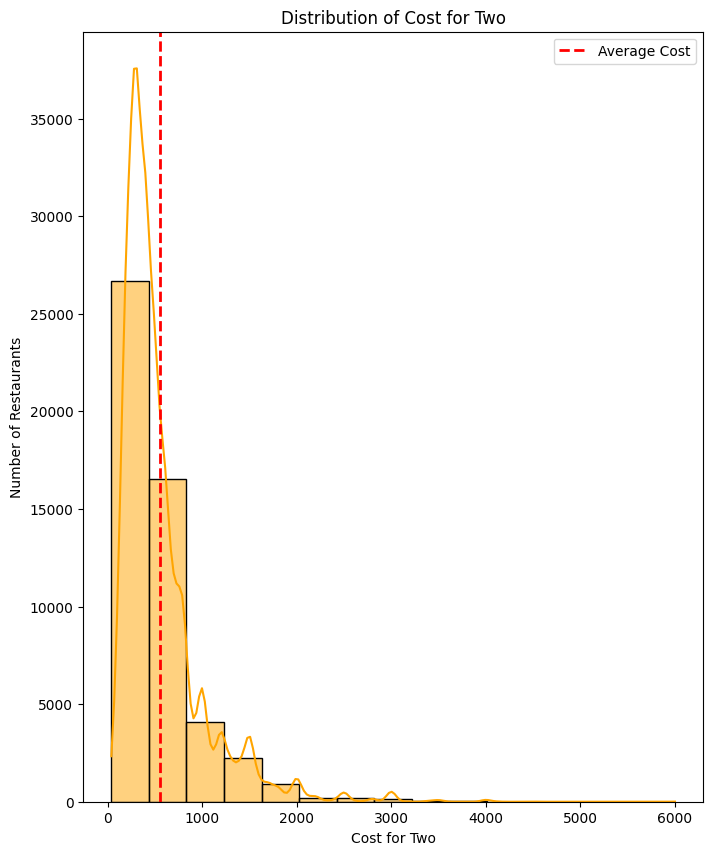

In [ ]:
# Analysis 10
# How is the Cost for Two distributed among restaurants?

# Create a figure
plt.figure(figsize=(8, 10))

# Plot histogram with KDE (Kernel Density Estimate)
sns.histplot(
    data=df,
    x='cost_for_two',
    bins=15,
    kde=True,
    color='orange',
    edgecolor='black'
)

# Draw a vertical line representing the average cost
plt.axvline(
    x=df['cost_for_two'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Average Cost'
)

# Add chart title and labels
plt.title('Distribution of Cost for Two')

plt.xlabel('Cost for Two')

plt.ylabel('Number of Restaurants')

# Display legend
plt.legend()

#

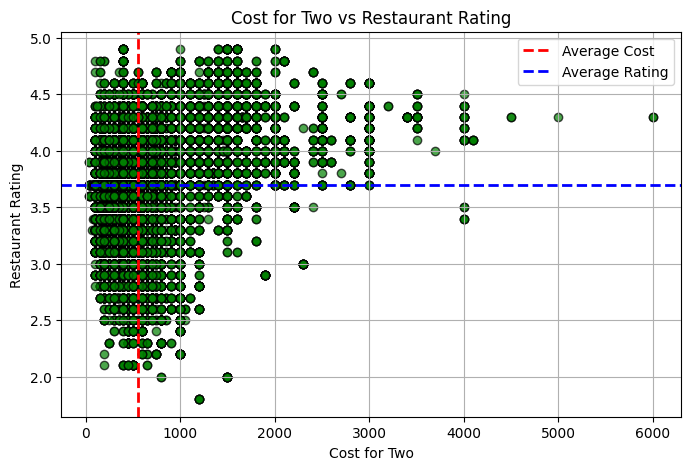

In [ ]:
# Analysis 11
# Is there any relationship between the Cost for Two and Restaurant Ratings?

# Create a figure
plt.figure(figsize=(8, 5))

# Create a scatter plot
plt.scatter(
    df['cost_for_two'],
    df['rating'],
    color='green',
    edgecolors='black',
    alpha=0.7
)

# Draw a vertical line representing the average cost
plt.axvline(
    x=df['cost_for_two'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Average Cost'
)

# Draw a horizontal line representing the average rating
plt.axhline(
    y=df['rating'].mean(),
    color='blue',
    linestyle='--',
    linewidth=2,
    label='Average Rating'
)

# Add chart title and labels
plt.title('Cost for Two vs Restaurant Rating')

plt.xlabel('Cost for Two')

plt.ylabel('Restaurant Rating')

# Display legend
plt.legend()

# Display grid
plt.grid(True)

# Display the graph
plt.show()

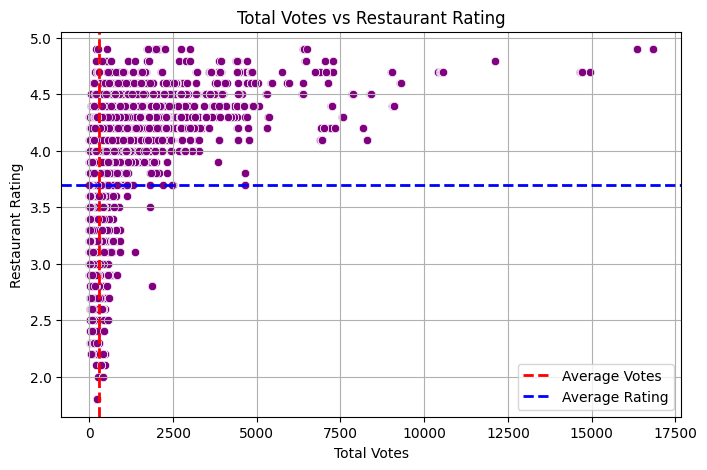

In [ ]:
# Analysis 12
# Is there any relationship between the Total Votes and Restaurant Ratings?

# Create a figure
plt.figure(figsize=(8, 5))

# Create a scatter plot
sns.scatterplot(
    data=df,
    x='total_votes',
    y='rating',
    color='purple'
)

# Draw a vertical line representing the average total votes
plt.axvline(
    x=df['total_votes'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Average Votes'
)

# Draw a horizontal line representing the average rating
plt.axhline(
    y=df['rating'].mean(),
    color='blue',
    linestyle='--',
    linewidth=2,
    label='Average Rating'
)

# Add chart title and labels
plt.title('Total Votes vs Restaurant Rating')

plt.xlabel('Total Votes')

plt.ylabel('Restaurant Rating')

# Display legend
plt.legend()

# Display grid
plt.grid(True)

# Display the graph
plt.show()

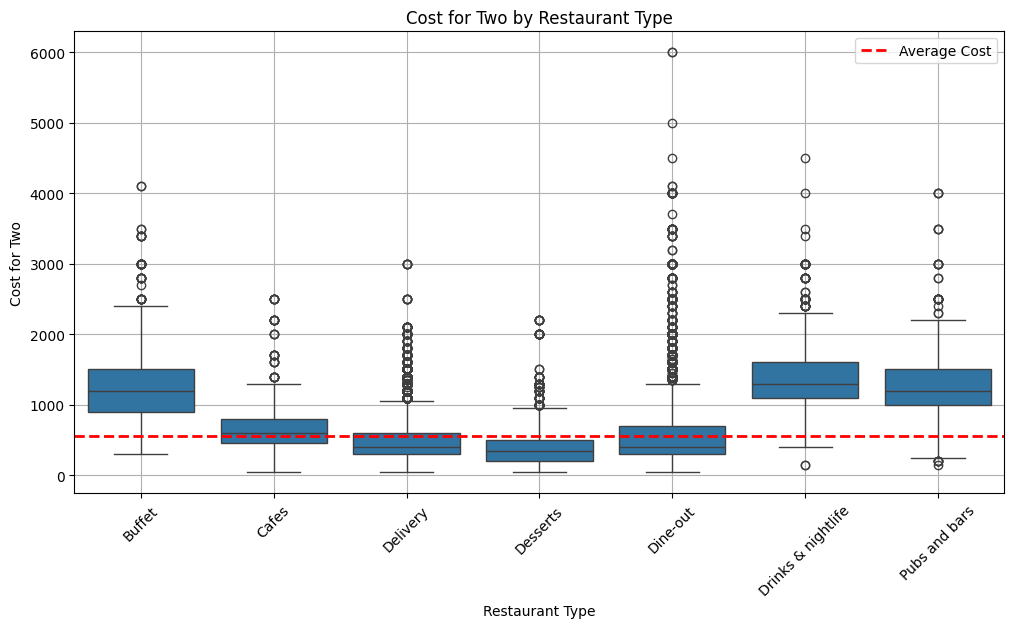

In [ ]:
# Analysis 16
# How does the Cost for Two vary across different Restaurant Types?

# Create a figure
plt.figure(figsize=(12, 6))

# Create a box plot
sns.boxplot(
    data=df,
    x='restaurant_type',
    y='cost_for_two'
)

# Draw a horizontal line representing the average cost
plt.axhline(
    y=df['cost_for_two'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Average Cost'
)

# Add chart title and labels
plt.title('Cost for Two by Restaurant Type')

plt.xlabel('Restaurant Type')

plt.ylabel('Cost for Two')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display legend
plt.legend()

# Display grid
plt.grid(True)

# Display the graph
plt.show()

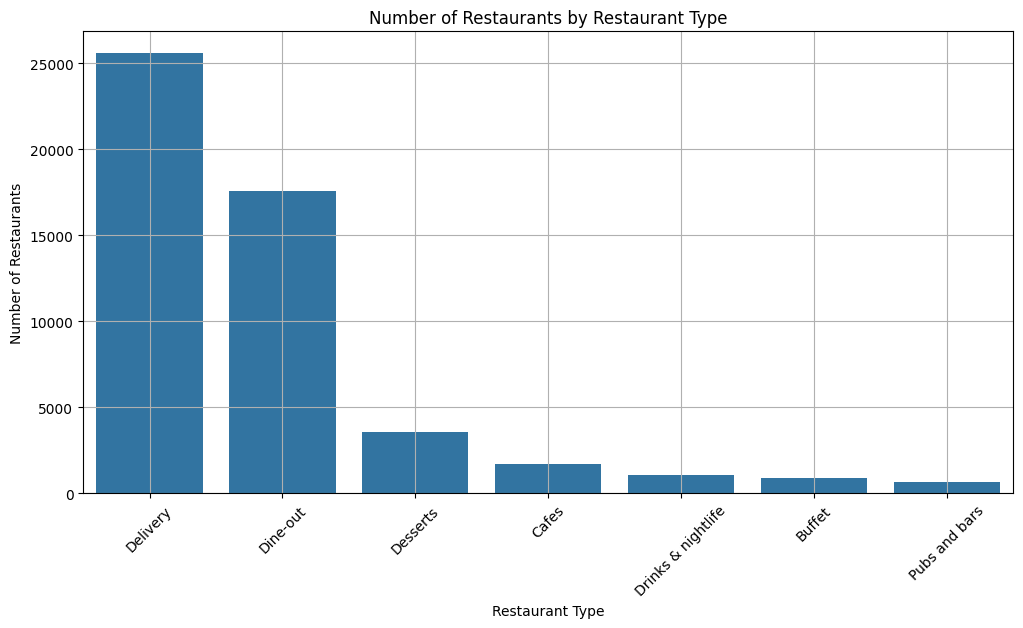

In [ ]:
# Analysis 14
# How many restaurants belong to each Restaurant Type?

# Create a figure
plt.figure(figsize=(12, 6))

# Create a count plot
sns.countplot(
    data=df,
    x='restaurant_type',
    order=df['restaurant_type'].value_counts().index
)

# Add chart title and labels
plt.title('Number of Restaurants by Restaurant Type')

plt.xlabel('Restaurant Type')

plt.ylabel('Number of Restaurants')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display grid
plt.grid(True)

# Display the graph
plt.show()

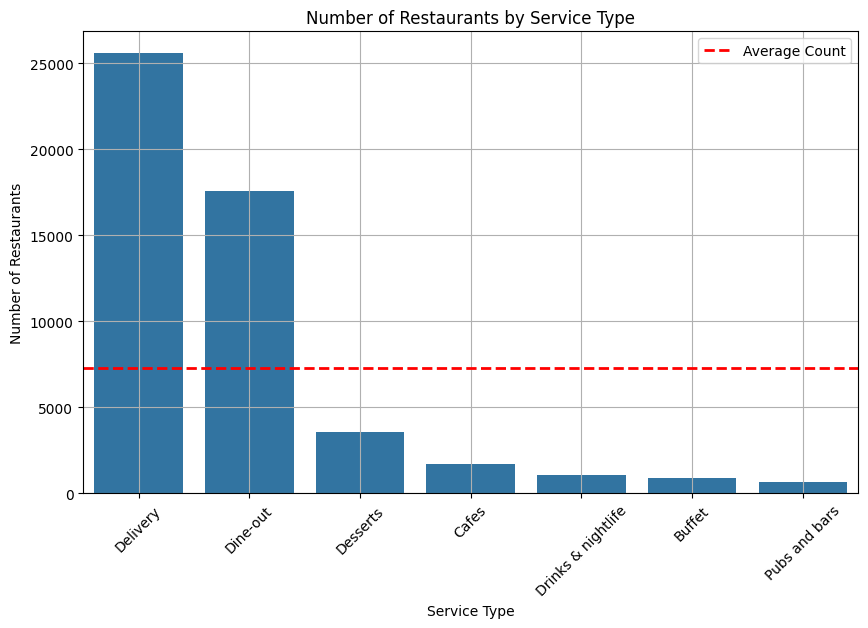

In [ ]:
# Analysis 15
# How many restaurants belong to each Service Type?

# Create a figure
plt.figure(figsize=(10, 6))

# Create a count plot
sns.countplot(
    data=df,
    x='restaurant_type',
    order=df['restaurant_type'].value_counts().index
)

# Draw a horizontal line representing the average number of restaurants
plt.axhline(
    y=df['restaurant_type'].value_counts().mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Average Count'
)

# Add chart title and labels
plt.title('Number of Restaurants by Service Type')

plt.xlabel('Service Type')

plt.ylabel('Number of Restaurants')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display legend
plt.legend()

# Display grid
plt.grid(True)

# Display the graph
plt.show()

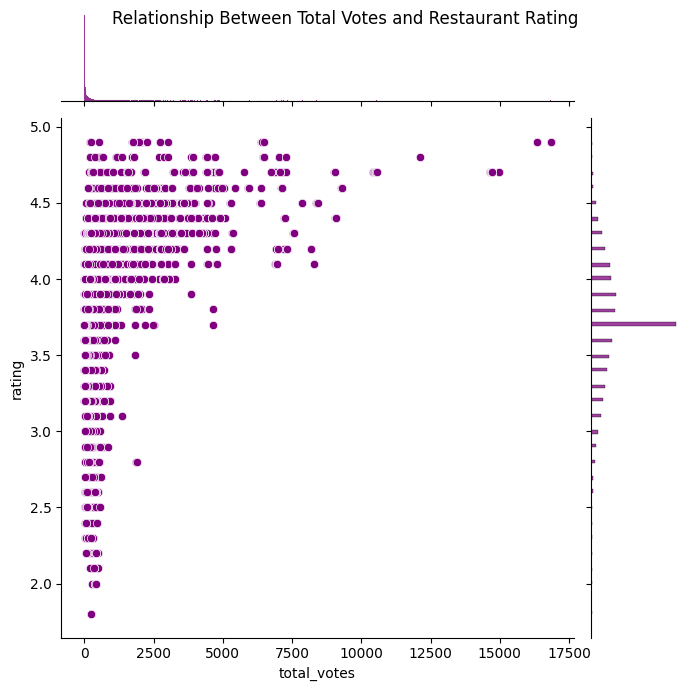

In [ ]:
# Analysis 16
# Is there any relationship between the Total Votes and Restaurant Ratings?

# Create a joint plot
sns.jointplot(
    data=df,
    x='total_votes',
    y='rating',
    kind='scatter',
    height=7,
    color='purple'
)

# Add a title
plt.suptitle('Relationship Between Total Votes and Restaurant Rating')

# Display the graph
plt.show()

In [ ]:
# Analysis 21
# What is the average restaurant rating at each location?

# Create a pivot table
location_rating = pd.pivot_table(
    data=df,
    values='rating',
    index='restaurant_location',
    aggfunc='mean'
)

# Convert the pivot table into a DataFrame
location_rating = pd.DataFrame(location_rating)

# Convert the index into a normal column
location_rating.reset_index(inplace=True)

# Display the pivot table
location_rating



,restaurant_location,rating
0,Banashankari,3.658672
1,Banaswadi,3.555508
2,Bannerghatta Road,3.555286
3,Basavanagudi,3.674872
4,Bellandur,3.567617
5,Brigade Road,3.703655
6,Brookefield,3.616945
7,Btm,3.601635
8,Church Street,3.979158
9,Commercial Street,3.597065


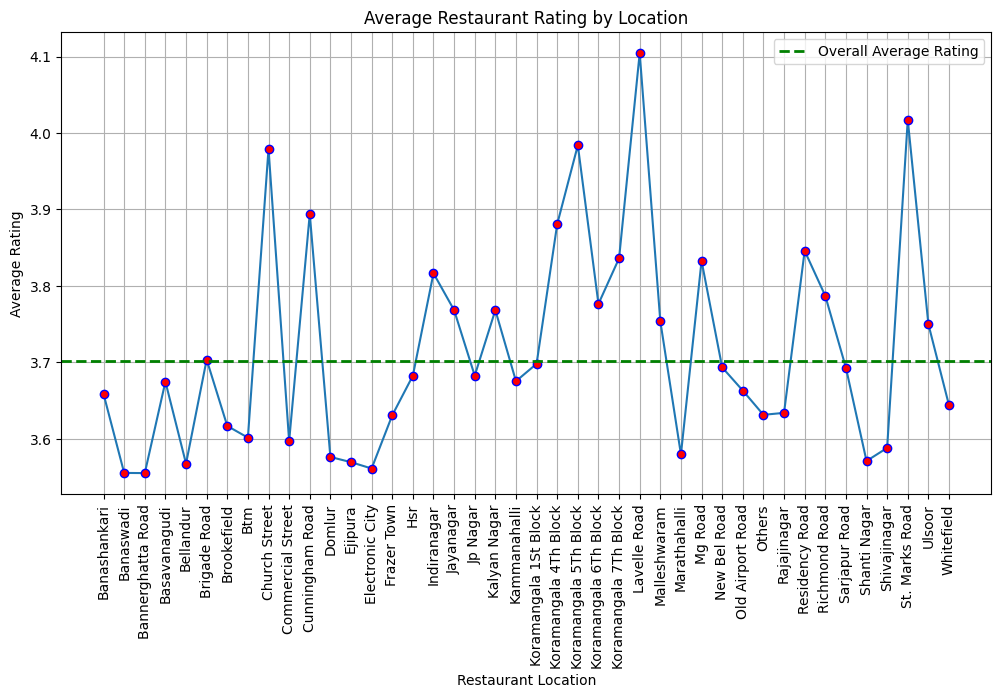

In [ ]:
# Create a figure
plt.figure(figsize=(12, 6))

# Plot the data
plt.plot(
    location_rating['restaurant_location'],
    location_rating['rating'],
    marker='o',
    markerfacecolor='red',
    markeredgecolor='blue'
)

# Draw a horizontal line representing the average rating
plt.axhline(
    y=df['rating'].mean(),
    color='green',
    linestyle='--',
    linewidth=2,
    label='Overall Average Rating'
)

# Add chart title and labels
plt.title('Average Restaurant Rating by Location')

plt.xlabel('Restaurant Location')

plt.ylabel('Average Rating')

# Rotate x-axis labels
plt.xticks(rotation=90)

# Display legend
plt.legend()

# Display grid
plt.grid(True)

# Display the graph
plt.show()

In [ ]:
# Analysis 22
# What is the average Cost for Two for each Cuisine Type?

# Create a pivot table
cuisine_cost = pd.pivot_table(
    data=df,
    values='cost_for_two',
    index='cuisines',
    aggfunc='mean'
)

cuisine_cost

,cost_for_two
cuisines,
Andhra,405.621302
"Andhra, Biryani",474.825175
Arabian,396.103896
Bakery,330.662558
"Bakery, Desserts",414.610245
...,...
"South Indian, Fast Food",259.615385
"South Indian, North Indian",373.293769
"South Indian, North Indian, Chinese",365.566298


                                            cuisines  cost_for_two
0                                             Andhra    405.621302
1                                    Andhra, Biryani    474.825175
2                                            Arabian    396.103896
3                                             Bakery    330.662558
4                                   Bakery, Desserts    414.610245
..                                               ...           ...
65                           South Indian, Fast Food    259.615385
66                        South Indian, North Indian    373.293769
67               South Indian, North Indian, Chinese    365.566298
68  South Indian, North Indian, Chinese, Street Food    324.462366
69                                       Street Food    177.098039

[70 rows x 2 columns]


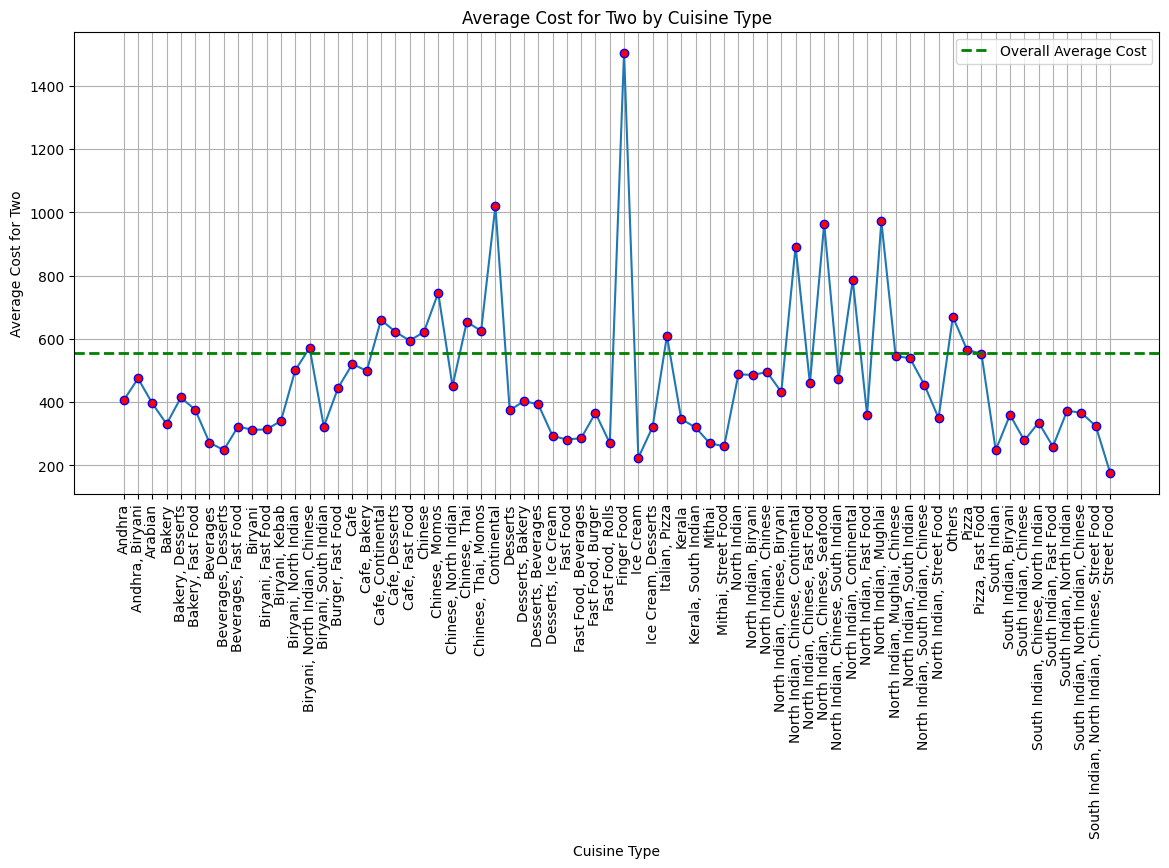

In [ ]:
# Convert the pivot table into a DataFrame
cuisine_cost = pd.DataFrame(cuisine_cost)

# Convert the index into a normal column
cuisine_cost.reset_index(inplace=True)

# Display the pivot table
print(cuisine_cost)

# Create a figure
plt.figure(figsize=(14, 6))

# Plot the data
plt.plot(
    cuisine_cost['cuisines'],
    cuisine_cost['cost_for_two'],
    marker='o',
    markerfacecolor='red',
    markeredgecolor='blue'
)

# Draw a horizontal line representing the overall average cost
plt.axhline(
    y=df['cost_for_two'].mean(),
    color='green',
    linestyle='--',
    linewidth=2,
    label='Overall Average Cost'
)

# Add chart title and labels
plt.title('Average Cost for Two by Cuisine Type')

plt.xlabel('Cuisine Type')

plt.ylabel('Average Cost for Two')

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Display legend
plt.legend()

# Display grid
plt.grid(True)

# Display the graph
plt.show()

In [ ]:
    # Analysis 23
    # How many restaurants are available for each Service Type?

    # Create a pivot table
    service_count = pd.pivot_table(
        data=df,
        values='restaurant_name',
        index='restaurant_type',
        aggfunc='count'
    )

    # Convert the pivot table into a DataFrame
    service_count = pd.DataFrame(service_count)

    # Convert the index into a normal column
    service_count.reset_index(inplace=True)

    # Display the pivot table
    service_count



/tmp/ipykernel_565/1314578347.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  service_count = pd.pivot_table(


,restaurant_type,restaurant_name
0,Buffet,869
1,Cafes,1703
2,Delivery,25579
3,Desserts,3559
4,Dine-out,17562
5,Drinks & nightlife,1084
6,Pubs and bars,686


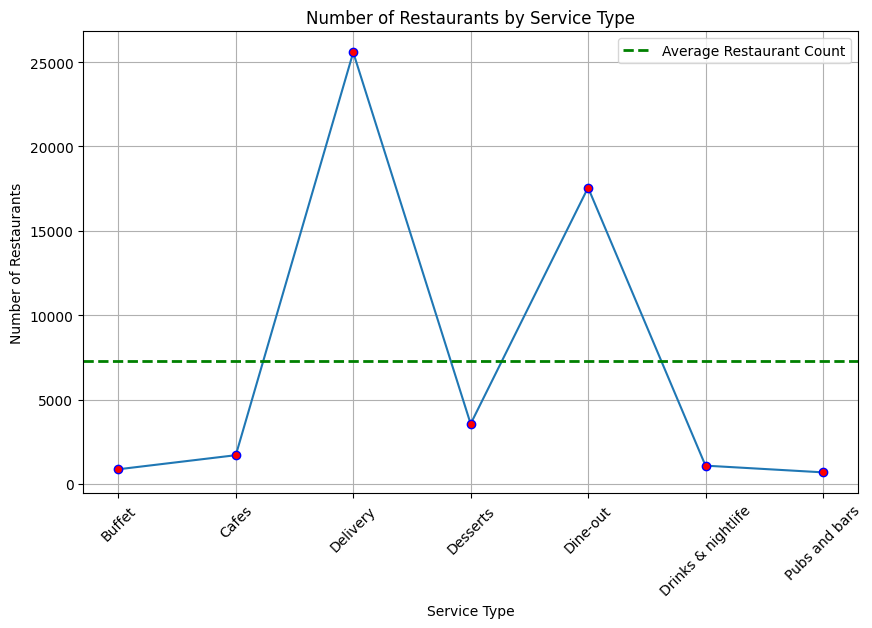

In [ ]:
# Create a figure
plt.figure(figsize=(10, 6))

# Plot the data
plt.plot(
        service_count['restaurant_type'],
        service_count['restaurant_name'],
        marker='o',
        markerfacecolor='red',
        markeredgecolor='blue'
    )

# Draw a horizontal line representing the average number of restaurants
plt.axhline(
        y=service_count['restaurant_name'].mean(),
        color='green',
        linestyle='--',
        linewidth=2,
        label='Average Restaurant Count'
    )

# Add chart title and labels
plt.title('Number of Restaurants by Service Type')

plt.xlabel('Service Type')

plt.ylabel('Number of Restaurants')

# Rotate x-axis labels
plt.xticks(rotation=45)

# Display legend
plt.legend()

# Display grid
plt.grid(True)

# Display the graph
plt.show()

/tmp/ipykernel_565/2846136863.py:84: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  online = df.groupby('online_order_available')['restaurant_name'].count()


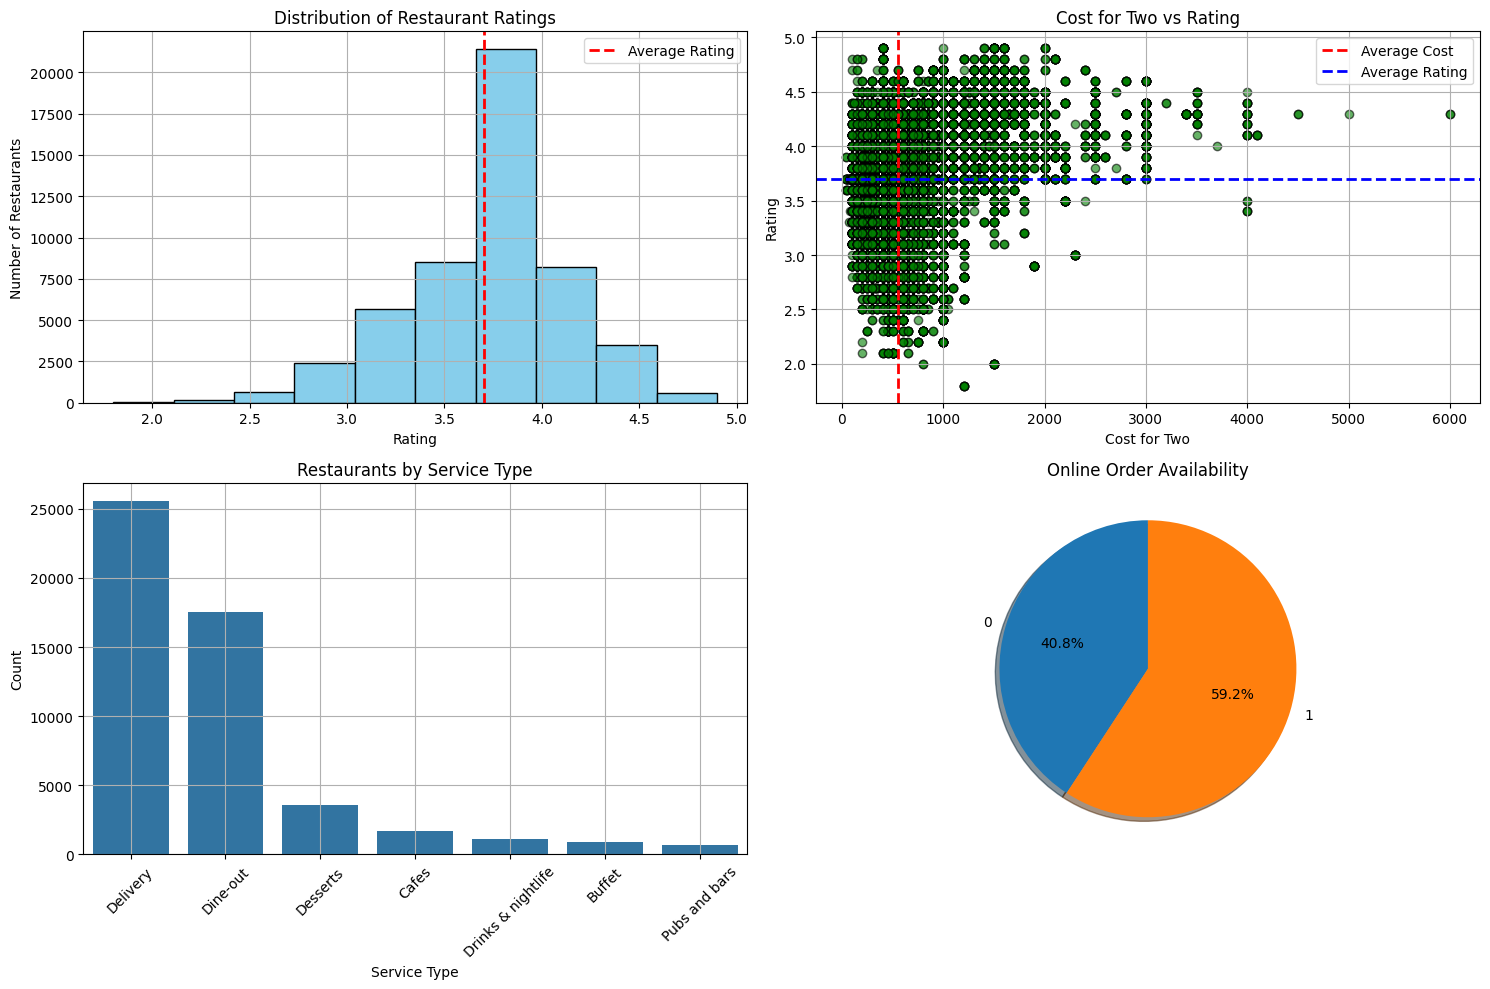

In [ ]:
# Analysis 24
# How do the distributions and relationships of Rating, Cost for Two,
# Total Votes, and Online Ordering compare in a single dashboard?

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ------------------------ Graph 1 ------------------------
# Histogram of Restaurant Ratings

axes[0, 0].hist(
    df['rating'],
    bins=10,
    color='skyblue',
    edgecolor='black'
)

axes[0, 0].axvline(
    x=df['rating'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Average Rating'
)

axes[0, 0].set_title('Distribution of Restaurant Ratings')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Number of Restaurants')
axes[0, 0].legend()
axes[0, 0].grid(True)

# ------------------------ Graph 2 ------------------------
# Scatter Plot of Cost vs Rating

axes[0, 1].scatter(
    df['cost_for_two'],
    df['rating'],
    color='green',
    edgecolors='black',
    alpha=0.6
)

axes[0, 1].axvline(
    x=df['cost_for_two'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Average Cost'
)

axes[0, 1].axhline(
    y=df['rating'].mean(),
    color='blue',
    linestyle='--',
    linewidth=2,
    label='Average Rating'
)

axes[0, 1].set_title('Cost for Two vs Rating')
axes[0, 1].set_xlabel('Cost for Two')
axes[0, 1].set_ylabel('Rating')
axes[0, 1].legend()
axes[0, 1].grid(True)

# ------------------------ Graph 3 ------------------------
# Count Plot of Restaurant Service Types

sns.countplot(
    data=df,
    x='restaurant_type',
    order=df['restaurant_type'].value_counts().index,
    ax=axes[1, 0]
)

axes[1, 0].set_title('Restaurants by Service Type')
axes[1, 0].set_xlabel('Service Type')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True)

# ------------------------ Graph 4 ------------------------
# Pie Chart of Online Order Availability

online = df.groupby('online_order_available')['restaurant_name'].count()

axes[1, 1].pie(
    online,
    labels=online.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)

axes[1, 1].set_title('Online Order Availability')

# Adjust spacing
plt.tight_layout()

# Display the dashboard
plt.show()

In [ ]:
# Analysis 25
# Which restaurant locations receive the highest average number of customer votes?

# Create a pivot table
location_votes = pd.pivot_table(
    data=df,
    values='total_votes',
    index='restaurant_location',
    aggfunc='mean'
)

location_votes

,total_votes
restaurant_location,
Banashankari,180.015521
Banaswadi,54.445312
Bannerghatta Road,133.616532
Basavanagudi,138.770468
Bellandur,161.914826
Brigade Road,352.629752
Brookefield,181.344512
Btm,113.462816
Church Street,1042.943463


In [ ]:
# Convert the pivot table into a DataFrame
location_votes = pd.DataFrame(location_votes)

location_votes

,total_votes
restaurant_location,
Banashankari,180.015521
Banaswadi,54.445312
Bannerghatta Road,133.616532
Basavanagudi,138.770468
Bellandur,161.914826
Brigade Road,352.629752
Brookefield,181.344512
Btm,113.462816
Church Street,1042.943463


In [ ]:
# Convert the index into a normal column
location_votes.reset_index(inplace=True)

# Display the pivot table
location_votes



,restaurant_location,total_votes
0,Banashankari,180.015521
1,Banaswadi,54.445312
2,Bannerghatta Road,133.616532
3,Basavanagudi,138.770468
4,Bellandur,161.914826
5,Brigade Road,352.629752
6,Brookefield,181.344512
7,Btm,113.462816
8,Church Street,1042.943463
9,Commercial Street,69.089189


In [ ]:
# Sort the values in descending order
location_votes.sort_values(
    by='total_votes',
    ascending=False,
    inplace=True
)

location_votes

,restaurant_location,total_votes
8,Church Street,1042.943463
26,Lavelle Road,957.098456
23,Koramangala 5Th Block,893.135539
39,St. Marks Road,775.798834
22,Koramangala 4Th Block,673.703048
10,Cunningham Road,586.675510
16,Indiranagar,575.473346
29,Mg Road,479.581187
34,Residency Road,432.955291
25,Koramangala 7Th Block,415.864566


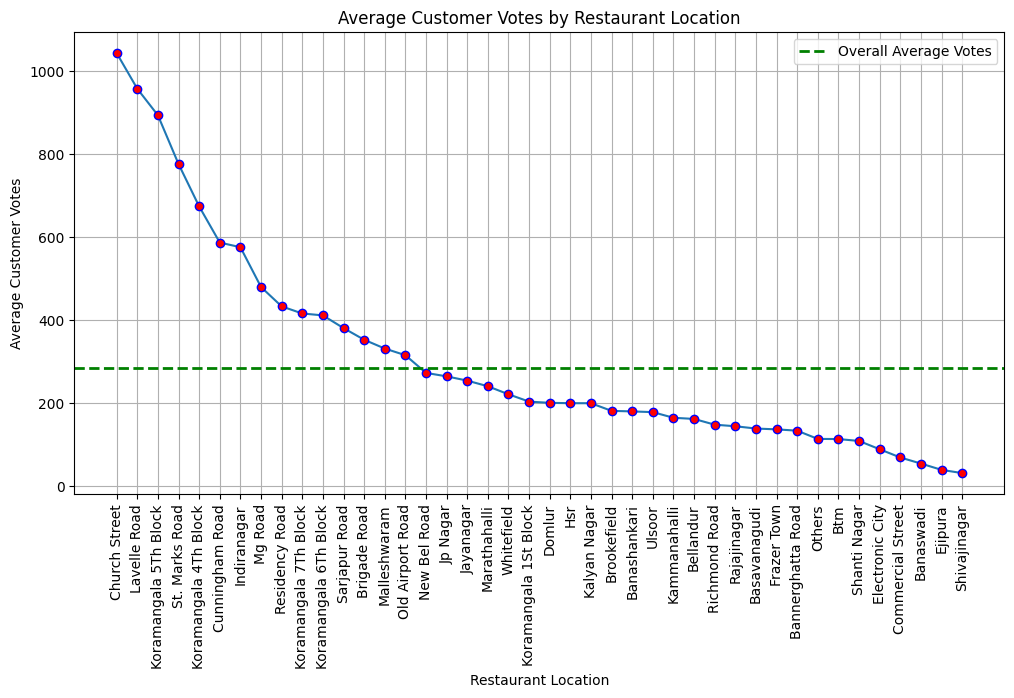

In [ ]:
# Create a figure
plt.figure(figsize=(12, 6))

# Plot the data
plt.plot(
    location_votes['restaurant_location'],
    location_votes['total_votes'],
    marker='o',
    markerfacecolor='red',
    markeredgecolor='blue'
)

# Draw a horizontal line representing the overall average votes
plt.axhline(
    y=df['total_votes'].mean(),
    color='green',
    linestyle='--',
    linewidth=2,
    label='Overall Average Votes'
)

# Add chart title and labels
plt.title('Average Customer Votes by Restaurant Location')

plt.xlabel('Restaurant Location')

plt.ylabel('Average Customer Votes')

# Rotate x-axis labels
plt.xticks(rotation=90)

# Display legend
plt.legend()

# Display grid
plt.grid(True)

# Display the graph
plt.show()